# 02-Function Calling & Tool Execution

In Lesson 01, we established the physics of the ReAct agent. We proved that an LLM can navigate a multi-step problem using a `while` loop that alternates between *Thoughts*, *Actions*, and *Observations*.

However, we glossed over a massive mechanical mystery: **How does a neural network actually interact with the external world?**
An LLM is just a giant matrix multiplication engine. It takes in tokens and predicts the next token. It does not have hands. It cannot click buttons, it cannot open a database connection, and it cannot execute a Python script.

To bridge the gap between the mathematical weights of the GPU and the physical execution of your server, we must master the architecture of **Function Calling**.

Let's set up our environment to engineer the exact data structures required to bind an LLM to a Python function.

In [1]:
import json
import inspect
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Function Calling Environment Ready.")


✅ Systems Architecture & Function Calling Environment Ready.


# 1. The Physics of Function Calling

The term "Function Calling" (or "Tool Calling") is actually a misnomer. **The LLM does not call the function.** The physical mechanism operates strictly as follows:

1. **The Binding**: You write a Python function. You translate the Python function's definition (its inputs, types, and descriptions) into a strict JSON Schema. You append this schema to the LLM's system prompt.
2. **The Generation**: The LLM reads the user's prompt. If it decides it needs the tool, it does not execute code; instead, it generates a text string formatted as a **JSON Object** that perfectly matches your schema.
3. **The Execution**: The LLM halts generation. Your Python server reads the LLM's text, parses it via `json.loads()`, and maps the extracted variables into the actual Python function using `kwargs`.
4. **The Return**: Your Python server executes the code, captures the output, and feeds it back into the LLM as a new user message labeled "Tool Response".

# 2. The Mathematics of Schema Alignment

For this to work, modern foundation models (like GPT-4, Claude 3, and Llama-3) are explicitly fine-tuned on millions of tool-calling JSON schema pairs.

Let $\mathcal{F}$ be a Python function, and $\mathcal{S}$ be its JSON schema representation.
When generating the next action $a_t$, the LLM calculates the joint probability of the required tool name and the syntactic distribution of the arguments $\theta$:

$$P(a_t | s_t, \mathcal{S}) = \prod_{i=1}^{|\theta|} P(\theta_i | \theta_{<i}, s_t, \mathcal{S})$$

If $\mathcal{S}$ strictly defines `{"type": "integer", "minimum": 1}`, the fine-tuned attention heads mathematically suppress the logits for string tokens (like `"five"`), forcing the model to output the raw integer token `5`.

# 3. Architecting the Tool Execution Engine

Let's build a raw, zero-abstraction Function Calling pipeline. We will define a real Python function, dynamically generate its JSON Schema, simulate the LLM's JSON string generation, and execute the physical handoff.

In [2]:
# --- 🛠️ The Real Function Calling Pipeline (LangChain bind_tools) ---

# 1. Define the physical Python function as a LangChain @tool.
# LangChain automatically converts the function signature + docstring
# into the JSON Schema that is injected into the LLM's system prompt.
@tool
def fetch_database_records(table_name: str, limit: int = 5) -> str:
    """Fetches records from the secure internal PostgreSQL database.
    
    Args:
        table_name: The name of the SQL table to query.
        limit: The maximum number of records to return.
    """
    print(f"\n[SERVER] 🔌 Executing SQL query on table '{table_name}' with limit {limit}...")
    if table_name == "employees":
        return json.dumps([{"id": 1, "name": "Sarah"}, {"id": 2, "name": "John"}])
    return "[]"

# 2. Show the auto-generated JSON Schema (what the LLM actually sees)
print("--- 📜 The LLM System Payload (Tool Binding) ---")
print(json.dumps(fetch_database_records.args_schema.model_json_schema(), indent=2))

# 3. Bind the tool to the LLM — the model now knows it can call this function
llm = ChatOllama(model="llama3.2", temperature=0)
llm_with_tools = llm.bind_tools([fetch_database_records])

# 4. Send a natural-language request — the LLM decides to use the tool
user_prompt = "Get me the first 2 employees from the database."
print(f"\n--- 🧑 User Prompt ---")
print(user_prompt)

response = llm_with_tools.invoke([HumanMessage(content=user_prompt)])

print(f"\n--- 🤖 The LLM Response (Tool Call) ---")
print(f"Content: {repr(response.content)}")    # usually empty when tool is called
print(f"Tool Calls: {response.tool_calls}")

# 5. The Execution Handoff — Python server executes the actual function
print("\n--- ⚙️ Execution Handoff ---")
for tool_call in response.tool_calls:
    print(f"Tool called: {tool_call['name']}")
    print(f"Arguments:   {tool_call['args']}")
    
    # Invoke the real Python function with the LLM-provided arguments
    observation = fetch_database_records.invoke(tool_call['args'])
    
    print(f"\n--- 👁️ The Tool Observation (Returned to LLM) ---")
    print(observation)

print("\n--- 💡 Engineering Insight ---")
print("Look at 'Tool Calls' above. The LLM output was NOT a natural-language sentence.")
print("It output a structured JSON object that precisely matched the function signature.")
print("LangChain's bind_tools() injects the JSON Schema into the system prompt, causing")
print("the model to suppress free text and output a tool-call payload instead.")
print("The Python server then reads this payload and executes the real function.")
print("The LLM itself never touched the database — it only generated the intent.")


--- 📜 The LLM System Payload (Tool Binding) ---
{
  "description": "Fetches records from the secure internal PostgreSQL database.\n\nArgs:\n    table_name: The name of the SQL table to query.\n    limit: The maximum number of records to return.",
  "properties": {
    "table_name": {
      "title": "Table Name",
      "type": "string"
    },
    "limit": {
      "default": 5,
      "title": "Limit",
      "type": "integer"
    }
  },
  "required": [
    "table_name"
  ],
  "title": "fetch_database_records",
  "type": "object"
}

--- 🧑 User Prompt ---
Get me the first 2 employees from the database.

--- 🤖 The LLM Response (Tool Call) ---
Content: ''
Tool Calls: [{'name': 'fetch_database_records', 'args': {'table_name': 'employees', 'limit': '2'}, 'id': '4561a1cd-e2e3-4a34-8312-e5fd71601e3d', 'type': 'tool_call'}]

--- ⚙️ Execution Handoff ---
Tool called: fetch_database_records
Arguments:   {'table_name': 'employees', 'limit': '2'}

[SERVER] 🔌 Executing SQL query on table 'employees' wi

# 4. Visualizing the execution Topology

To fully grasp the separation of concerns, we must visualize the **Air Gap** between the Neural Network (where text is generated) and the Server Runtime (where code is executed).

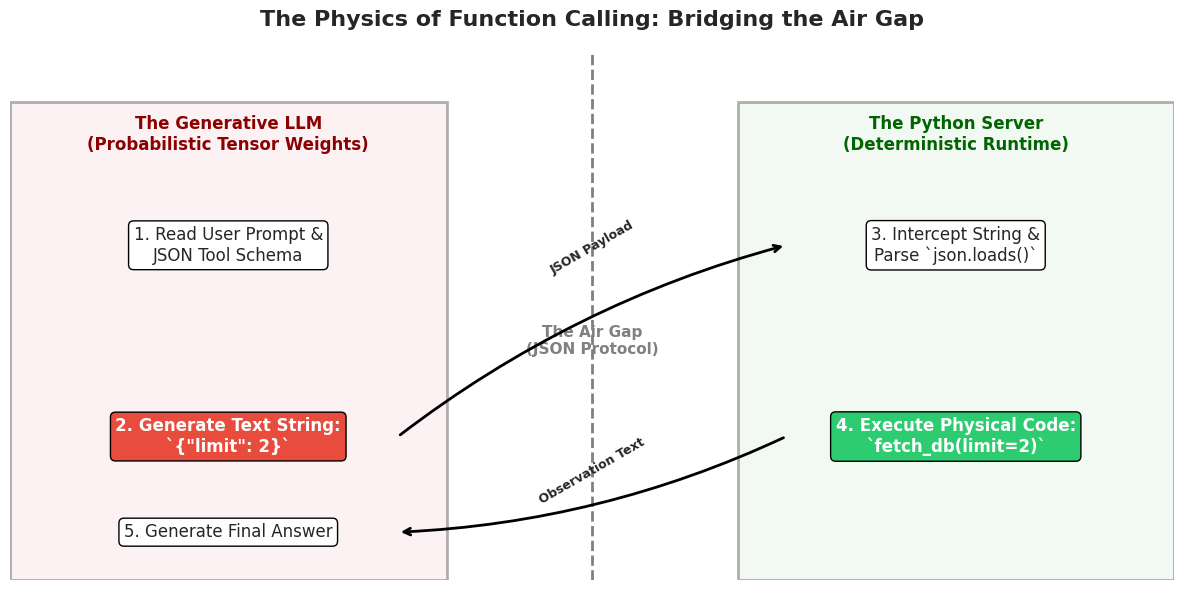


--- 💡 Engineering Insight ---
Look at the Air Gap. The Red Node (The LLM) has absolutely zero ability to execute the Green Node (The Code). The LLM is safely trapped inside its matrix multiplication. It can only generate text formatting requests across the Air Gap.
This architecture is fundamentally secure. If the LLM generates a malicious request: `{'table_name': 'DROP TABLE employees'}`, it cannot execute it! Your Python server intercepts the JSON, evaluates the parameters, and can implement strict security checks before allowing the code to run.


In [9]:
# Visualizing the Function Calling Air Gap
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("The Physics of Function Calling: Bridging the Air Gap", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Draw the two physical domains
# Domain A: The Generative AI (Cloud/GPU)
gpu_domain = patches.Rectangle((0, 0), 4.5, 5, linewidth=2, edgecolor='black', facecolor='#f8d7da', alpha=0.3, zorder=1)
ax.add_patch(gpu_domain)
ax.text(2.25, 4.5, "The Generative LLM\n(Probabilistic Tensor Weights)", ha='center', fontweight='bold', color='darkred')

# Domain B: The Python Server (Local/CPU)
cpu_domain = patches.Rectangle((7.5, 0), 4.5, 5, linewidth=2, edgecolor='black', facecolor='#d4edda', alpha=0.3, zorder=1)
ax.add_patch(cpu_domain)
ax.text(9.75, 4.5, "The Python Server\n(Deterministic Runtime)", ha='center', fontweight='bold', color='darkgreen')

# 2. Draw the Air Gap
ax.text(6, 2.5, "The Air Gap\n(JSON Protocol)", ha='center', va='center', fontweight='bold', fontsize=11, color='gray')
ax.axvline(x=6, color='black', linestyle='--', linewidth=2, alpha=0.5)

# 3. Draw the Nodes
# LLM Nodes
ax.text(2.25, 3.5, "1. Read User Prompt &\nJSON Tool Schema", ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.text(2.25, 1.5,"2. Generate Text String:\n`{\"limit\": 2}`",ha='center', va='center', color='white', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3",fc="#e74c3c",ec="black"))
ax.text(2.25, 0.5, "5. Generate Final Answer", ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

# Server Nodes
ax.text(9.75, 3.5, "3. Intercept String &\nParse `json.loads()`", ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.text(9.75, 1.5, "4. Execute Physical Code:\n`fetch_db(limit=2)`", ha='center', va='center', color='white', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#2ecc71", ec="black"))

# 4. Draw the Communication Arrows
# LLM to Server
ax.annotate("", xy=(8, 3.5), xytext=(4, 1.5), arrowprops=dict(arrowstyle="->", color="black", lw=2, connectionstyle="arc3,rad=-0.1"))
ax.text(6, 3.2, "JSON Payload", ha='center', fontsize=9, fontweight='bold', rotation=30)

# Server back to LLM
ax.annotate("", xy=(4, 0.5), xytext=(8, 1.5), arrowprops=dict(arrowstyle="->", color="black", lw=2, connectionstyle="arc3,rad=-0.1"))
ax.text(6, 0.8, "Observation Text", ha='center', fontsize=9, fontweight='bold', rotation=30)

plt.xlim(0, 12)
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Air Gap. The Red Node (The LLM) has absolutely zero ability to execute the Green Node (The Code). The LLM is safely trapped inside its matrix multiplication. It can only generate text formatting requests across the Air Gap.")
print("This architecture is fundamentally secure. If the LLM generates a malicious request: `{'table_name': 'DROP TABLE employees'}`, it cannot execute it! Your Python server intercepts the JSON, evaluates the parameters, and can implement strict security checks before allowing the code to run.")

## Real-World Use Case or Analogy:

Think of Function Calling like **Ordering Food at a Drive-Thru**:

* **The Customer (The LLM)**: The customer is hungry (User Prompt). The customer knows exactly what they want. However, the customer is sitting in their car. They do not have access to the deep fryers, the grills, or the refrigerators (The Air Gap). They cannot cook the food.
* **The Menu (The JSON Schema)**: The customer reads the drive-thru menu. The menu explicitly defines the inputs the restaurant accepts: *"Combo #1. Optional parameters: Size (Small/Medium/Large), Drink (Coke/Sprite)."*
* **The Order (The Function Call)**: The customer speaks into the microphone: *"I'll take a Combo #1, Large, with a Sprite."* (The LLM generates the JSON string).
* **The Kitchen (The Python Server)**: The cashier hears the order, validates that "Combo #1" and "Sprite" actually exist on the menu (Parsing the JSON), and hands the ticket to the cooks. The cooks physically execute the order (Running the Python Code).
* **The Observation**: The cashier hands the physical bag of food through the window back to the customer. The customer consumes it and completes their goal.